In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения графиков и таблиц
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Загрузка датасета
df = pd.read_csv('data/raw/housing.csv')

# Вывод необходымых параметров
print("Данные загружены")
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов")
print("\n Первые 5 строк:")
display(df.head())

print("\n Информация о типах и пропусках:")
df.info()

print("\n Базовая статистика по числовым признакам:")
display(df.describe())

print("\n Пропуски по столбцам:")
display(df.isnull().sum())

Данные загружены
Размер: 19195 строк × 10 столбцов

 Первые 5 строк:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



 Информация о типах и пропусках:
<class 'pandas.DataFrame'>
RangeIndex: 19195 entries, 0 to 19194
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19195 non-null  float64
 1   latitude            19195 non-null  float64
 2   housing_median_age  19195 non-null  float64
 3   total_rooms         19195 non-null  float64
 4   total_bedrooms      19006 non-null  float64
 5   population          19195 non-null  float64
 6   households          19195 non-null  float64
 7   median_income       19195 non-null  float64
 8   median_house_value  19195 non-null  float64
 9   ocean_proximity     19195 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.5 MB

 Базовая статистика по числовым признакам:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19195.000000,19195.000000,19195.000000,19195.000000,19006.000000,19195.000000,19195.000000,19195.000000,19195.000000
mean,-119.571967,35.634825,28.619745,2627.138421,535.979901,1421.067413,497.835530,3.876270,207062.917843
std,2.004638,2.136828,12.573811,2163.509711,418.839228,1129.249021,380.143585,1.911459,115668.000617
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1444.000000,295.000000,784.000000,279.000000,2.562500,119400.000000
50%,-118.500000,34.260000,29.000000,2122.000000,434.000000,1165.000000,409.000000,3.537900,179800.000000
75%,-118.010000,37.710000,37.000000,3142.000000,644.000000,1721.000000,602.000000,4.757150,265400.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



 Пропуски по столбцам:


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        189
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [3]:
target_col = 'median_house_value' 

y = df[target_col]
X = df.drop(columns=[target_col])

print(f"Целевая переменная: '{target_col}'")
print(f"Тип задачи: {'Регрессия' if y.dtype in ['float64', 'int64'] and y.nunique() > 20 else 'Классификация'}")
print(f"Распределение целевой переменной:")
display(y.describe())

Целевая переменная: 'median_house_value'
Тип задачи: Регрессия
Распределение целевой переменной:


count     19195.000000
mean     207062.917843
std      115668.000617
min       14999.000000
25%      119400.000000
50%      179800.000000
75%      265400.000000
max      500001.000000
Name: median_house_value, dtype: float64

In [4]:
# Разделяем признаки по типам
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Числовые признаки ({len(num_cols)}): {num_cols}")
print(f"Категориальные признаки ({len(cat_cols)}): {cat_cols}")

# Для категориальных: смотрим уникальные значения
if cat_cols:
    print("\n Уникальные значения в категориальных признаках:")
    for col in cat_cols:
        print(f"{col}: {X[col].nunique()} уникальных значений → {X[col].value_counts().head(3).to_dict()}")

Числовые признаки (8): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Категориальные признаки (1): ['ocean_proximity']

 Уникальные значения в категориальных признаках:
ocean_proximity: 5 уникальных значений → {'<1H OCEAN': 8515, 'INLAND': 6080, 'NEAR OCEAN': 2471}


C:\Users\Asus\AppData\Local\Temp\ipykernel_18452\4094396155.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


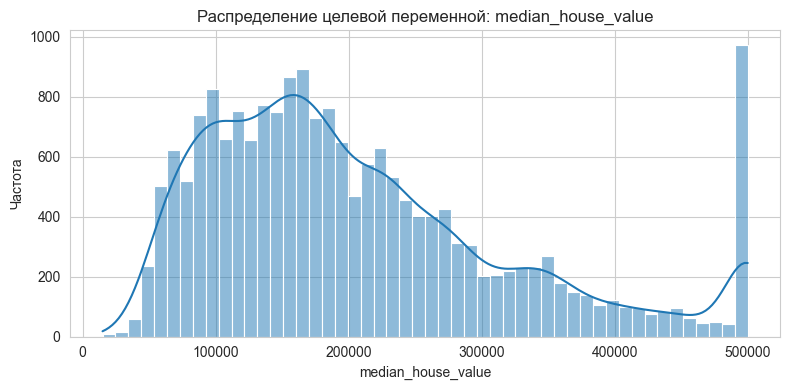

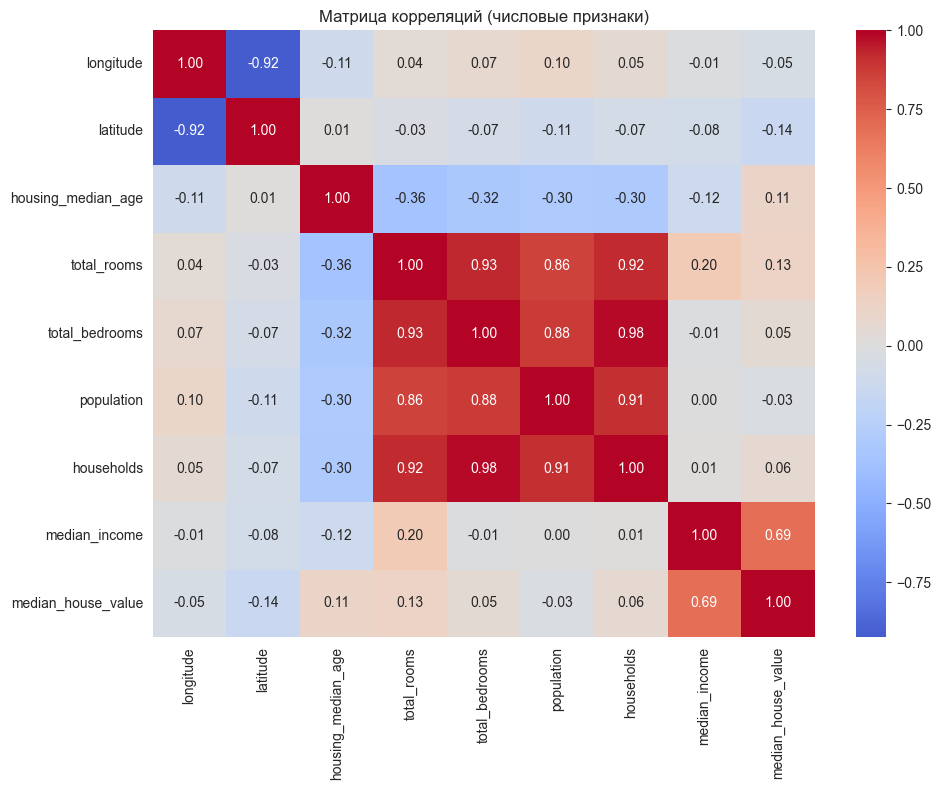


 Топ-5 признаков по корреляции с целевой переменной:


median_house_value    1.000000
median_income         0.688830
latitude              0.144646
total_rooms           0.132531
housing_median_age    0.106521
households            0.063839
Name: median_house_value, dtype: float64

In [ ]:
# Гистограмма целевой переменной
plt.figure(figsize=(8, 4))
sns.histplot(y, bins=50, kde=True)
plt.title(f'Распределение целевой переменной: {target_col}')
plt.xlabel(target_col)
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

# Тепловая карта корреляций (только числовые признаки)
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    corr_matrix = df[num_cols + [target_col]].corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Матрица корреляций (числовые признаки)')
    plt.tight_layout()
    plt.savefig('reports/The_heatma_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Топ-5 корреляций с целевой переменной
    print("\n Топ-5 признаков по корреляции с целевой переменной:")
    corr_with_target = corr_matrix[target_col].abs().sort_values(ascending=False)
    display(corr_with_target.head(6))  # первая — сама с собой

📊 Важность признаков (оценка через Random Forest):


,feature,importance
7,median_income,0.516403
0,longitude,0.109966
1,latitude,0.109726
8,ocean_proximity,0.109012
2,housing_median_age,0.054642
5,population,0.033192
3,total_rooms,0.025393
4,total_bedrooms,0.022685
6,households,0.018983


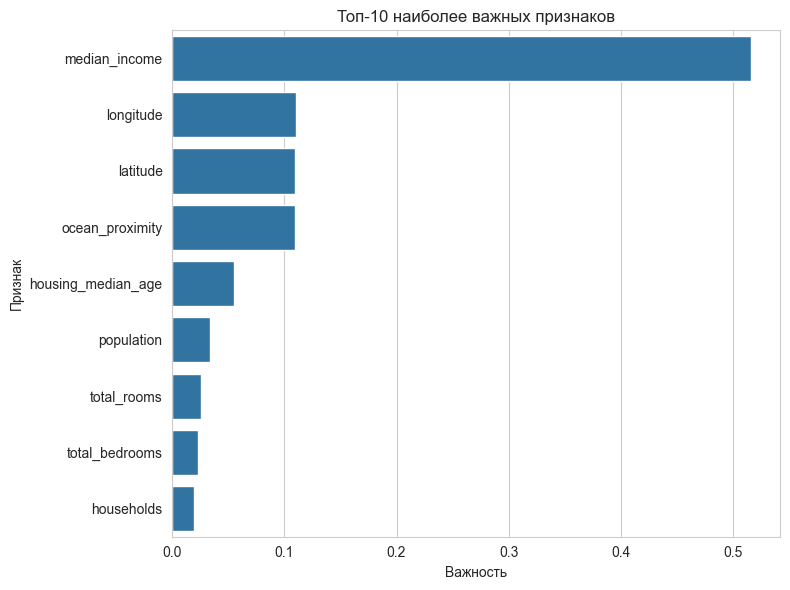

In [ ]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Копируем данные для кодирования
X_encoded = X.copy()

# Кодируем категориальные признаки (для быстрой оценки)
for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Выбираем модель в зависимости от типа задачи
if y.dtype in ['float64', 'int64'] and y.nunique() > 20:
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
else:
    model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# Удаляем пропуски для обучения (быстрая оценка)
mask = ~X_encoded.isnull().any(axis=1) & ~y.isnull()
model.fit(X_encoded[mask], y[mask])

# Feature Importance
fi = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("Важность признаков (оценка через Random Forest):")
display(fi.head(10))

# Визуализация топ-10 признаков
plt.figure(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=fi.head(10))
plt.title('Топ наиболее важных признаков')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()